# Diabetic Retinopathy

Diabetic retinopathy (DR), also known as diabetic eye disease, is a medical condition in which damage occurs to the retina due to diabetes mellitus. It is a leading cause of blindness. Diabetic retinopathy affects up to 80 percent of those who have had diabetes for 20 years or more. Diabetic retinopathy often has no early warning signs. **Retinal (fundus) photography with manual interpretation is a widely accepted screening tool for diabetic retinopathy**, with performance that can exceed that of in-person dilated eye examinations.

The below figure shows an example of a healthy patient and a patient with diabetic retinopathy as viewed by fundus photography ([source](https://www.biorxiv.org/content/biorxiv/early/2018/06/19/225508.full.pdf)):

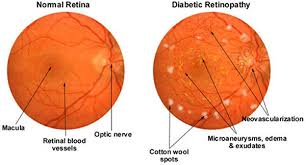

An automated tool for grading severity of diabetic retinopathy would be very useful for accerelating detection and treatment. Recently, there have been a number of attempts to utilize deep learning to diagnose DR and automatically grade diabetic retinopathy. This includes a previous [competition](https://kaggle.com/c/diabetic-retinopathy-detection) and [work by Google](https://ai.googleblog.com/2016/11/deep-learning-for-detection-of-diabetic.html). Even one deep-learning based system is [FDA approved](https://www.fda.gov/NewsEvents/Newsroom/PressAnnouncements/ucm604357.htm).

Clearly, this dataset and deep learning problem is quite important.

# A look at the data:

Data description from the competition:

>You are provided with a large set of high-resolution retina images taken under a variety of imaging conditions. A left and right field is provided for every subject. >Images are labeled with a subject id as well as either left or right (e.g. 1_left.jpeg is the left eye of patient id 1).
>
>A clinician has rated the presence of diabetic retinopathy in each image on a scale of 0 to 4, according to the following scale:
>
>0 - No DR
>
>1 - Mild
>
>2 - Moderate
>
>3 - Severe
>
>4 - Proliferative DR
>
>Your task is to create an automated analysis system capable of assigning a score based on this scale.

...

> Like any real-world data set, you will encounter noise in both the images and labels. Images may contain artifacts, be out of focus, underexposed, or overexposed. A major aim of this competition is to develop robust algorithms that can function in the presence of noise and variation.




# **INSTALL PACKAGES & IMPORT LIBRARIES**

In [1]:
!pip install kaggle

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od
od.download("https://www.kaggle.com/competitions/aptos2019-blindness-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: blessingasare1
Your Kaggle Key: ··········


100%|██████████| 9.51G/9.51G [00:27<00:00, 365MB/s]



Extracting archive ./aptos2019-blindness-detection/aptos2019-blindness-detection.zip to ./aptos2019-blindness-detection


In [4]:
# Mount the Google drive so you can store your kaggle API credentials for future use
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Import Libraries for EDA
import os
import cv2 as cv
import numpy as np
import pandas as pd
import seaborn as sns
from glob import glob
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

# Import Libraries for Data Preprocessing
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample, class_weight
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import Libraries for AI Model Training
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Input, Conv2D, Dropout, Flatten, Dense, MaxPool2D, GlobalAveragePooling2D, BatchNormalization

# Import Libraries for Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import classification_report

# **(A) EXPLORATORY DATA ANALYSIS (EDA)**

# MetaData

In [6]:
trnCsv = pd.read_csv("/content/aptos2019-blindness-detection/train.csv")
trnCsv.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


# Label Class Distribution

In [7]:
# --- By numeric code (0–4), preserving order and including zeros ---
print(trnCsv["diagnosis"].value_counts())

diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


# **(B) DATA PREPROCESSING**

# Resample Data for Balancing

In [8]:
# Balance data. Separate each class, resample, and combine back into a single dataframe.
class_0 = trnCsv[trnCsv['diagnosis'] == 0]  # No DR
class_1 = trnCsv[trnCsv['diagnosis'] == 1]  # Mild
class_2 = trnCsv[trnCsv['diagnosis'] == 2]  # Moderate
class_3 = trnCsv[trnCsv['diagnosis'] == 3]  # Severe
class_4 = trnCsv[trnCsv['diagnosis'] == 4]  # Proliferative DR

# n_samples=1000
class_0_balanced = resample(class_0, replace=False, n_samples=1000, random_state=42)
class_1_balanced = resample(class_1, replace=True, n_samples=970, random_state=42)
# class_2_balanced = resample(class_2, replace=False, n_samples=999, random_state=42)
class_2_balanced = class_2
class_3_balanced = resample(class_3, replace=True, n_samples=893, random_state=42)
class_4_balanced = resample(class_4, replace=True, n_samples=895, random_state=42)

# Combine the resampled classes back together
balanced_df = pd.concat([class_0_balanced, class_1_balanced, class_2_balanced, class_3_balanced, class_4_balanced])

# Check the new class distribution. All classes should be balanced now.
print(balanced_df['diagnosis'].value_counts())

diagnosis
0    1000
2     999
1     970
4     895
3     893
Name: count, dtype: int64


# Merge Images & MetaData

In [9]:
# SIZE = 32
SIZE = 224

# Now it's time to read images based on image ID from the CSV file
# This is the safest way to read images as it ensures the right image is read for the right ID
image_path = {os.path.splitext(os.path.basename(x))[0]: x for x in tqdm(glob(os.path.join('/content/aptos2019-blindness-detection/train_images', '*.png')))}

# Define the path and add as a new column
balanced_df['path'] = trnCsv['id_code'].map(image_path.get)
# Use the path to read images.
balanced_df['image'] = balanced_df['path'].map(lambda x: np.asarray(Image.open(x).resize((SIZE,SIZE))))


100%|██████████| 3662/3662 [00:00<00:00, 745464.05it/s]


In [10]:
balanced_df.head()

,id_code,diagnosis,path,image
3444,ef5155990874,0,/content/aptos2019-blindness-detection/train_i...,"[[[3, 2, 0], [2, 1, 0], [2, 1, 0], [2, 1, 0], ..."
141,0a85a1e8f9e9,0,/content/aptos2019-blindness-detection/train_i...,"[[[9, 8, 13], [9, 8, 13], [9, 8, 13], [9, 8, 1..."
1509,6a2642131e4a,0,/content/aptos2019-blindness-detection/train_i...,"[[[2, 1, 0], [2, 1, 0], [2, 1, 0], [2, 1, 0], ..."
1970,8a8a251770cd,0,/content/aptos2019-blindness-detection/train_i...,"[[[2, 0, 1], [2, 0, 1], [2, 0, 1], [1, 1, 0], ..."
2482,ac1667fac512,0,/content/aptos2019-blindness-detection/train_i...,"[[[2, 1, 0], [2, 1, 0], [2, 1, 0], [2, 1, 0], ..."


# Plot Visualizations

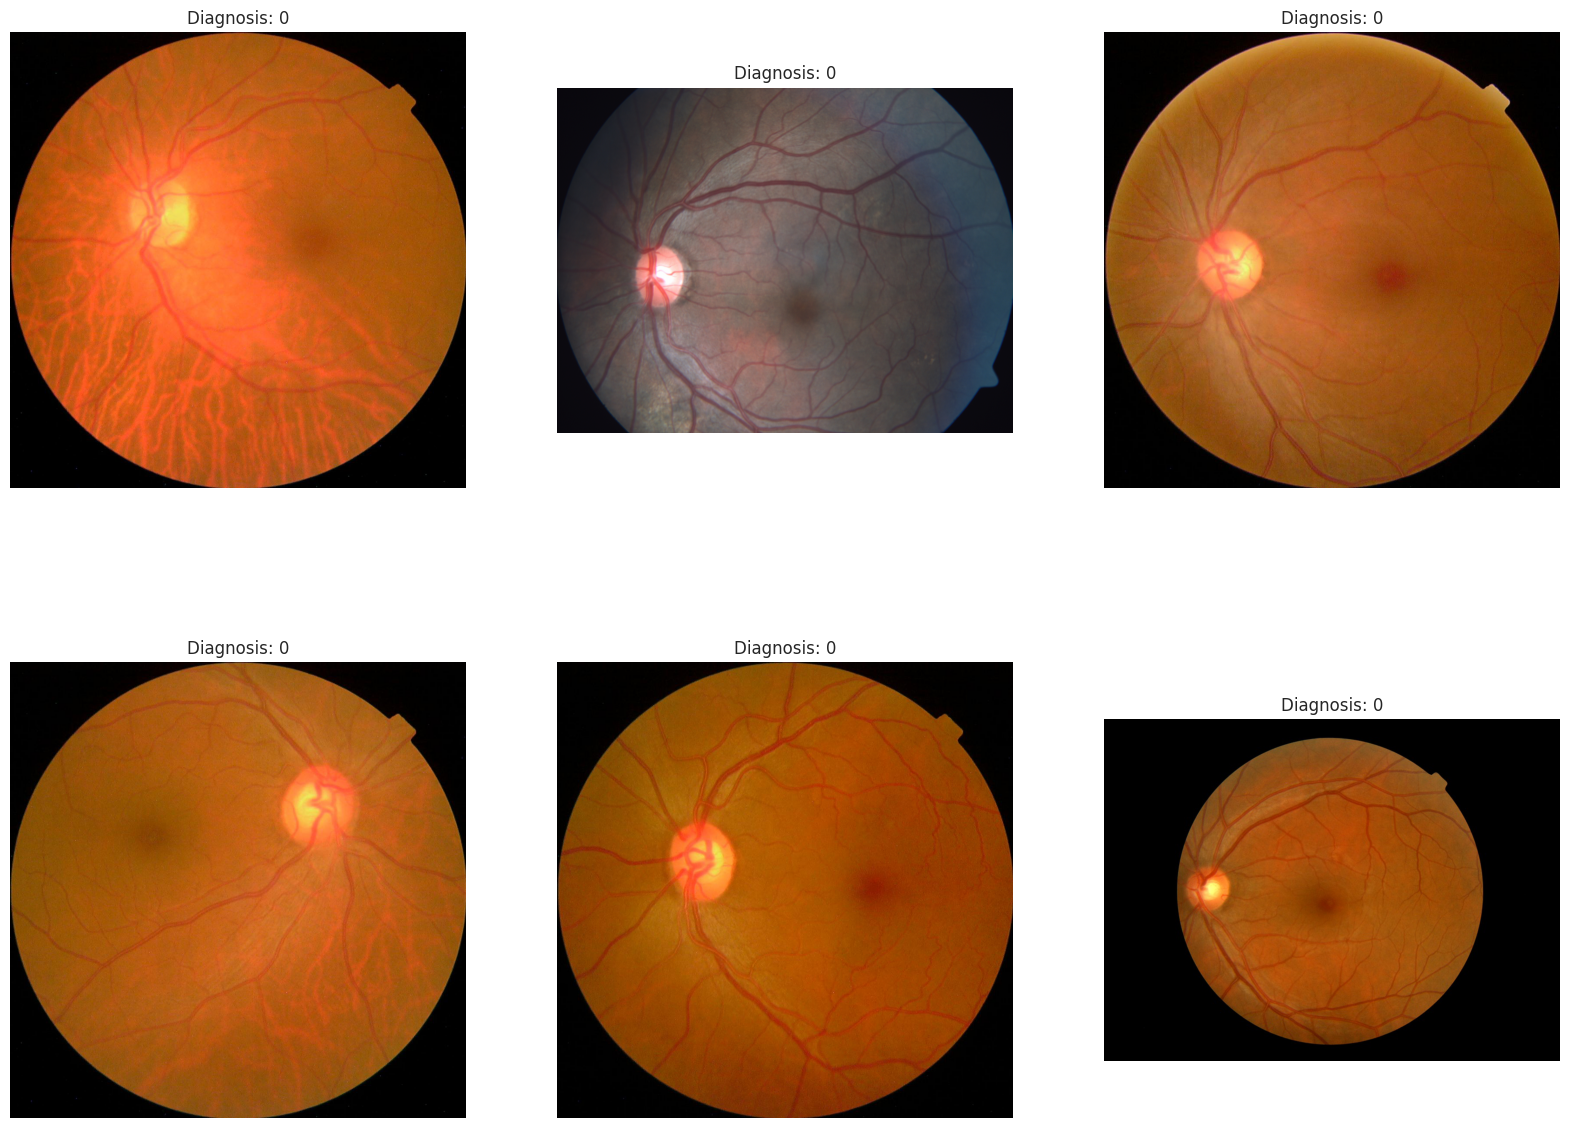

In [11]:
sns.set_style("white")
plt.figure(figsize = [20, 15])
for i, (image_path, ground_truth) in enumerate(zip(balanced_df["path"][:6], balanced_df["diagnosis"][:6])):
    title = f"Diagnosis: {ground_truth}"                   # Set the title based on ground truth
    image_data = cv.imread(image_path)                     # Read the image data using OpenCV
    plt.subplot(2, 3, i + 1)                               # Plot the image
    plt.imshow(cv.cvtColor(image_data, cv.COLOR_BGR2RGB))  # Convert BGR to RGB for proper display
    plt.axis("off"); plt.title(title)

plt.show()

# Data Splitting

In [12]:
# Convert dataframe column of images into numpy array
X = np.asarray(balanced_df['image'].tolist())

In [13]:
X     = X/255.                           # Scale values to 0-1.
Y     = balanced_df['diagnosis']         # Assign label values to Y
Y_cat = to_categorical(Y, num_classes=5) # Convert to categorical as this is a multiclass classification problem

# -----: Training Data
# Split the training data into (80% training, 20% validation)
X_trn, X_valtst, y_trn, y_valtst = train_test_split(X, Y_cat, test_size=0.2, random_state=42)
X_val, X_tst, y_val, y_tst = train_test_split(X_valtst, y_valtst, test_size=0.2, random_state=42)

In [14]:
# Display the shapes of the training, validation and testing sets
print(f"X_trn Shape: {X_trn.shape} | X_val Shape: {X_val.shape} | y_trn Shape: {y_trn.shape} | y_val Shape: {y_val.shape}, \n\nX_tst Shape: {X_tst.shape} | y_tst Shape: {y_tst.shape}")

X_trn Shape: (3805, 224, 224, 3) | X_val Shape: (761, 224, 224, 3) | y_trn Shape: (3805, 5) | y_val Shape: (761, 5), 

X_tst Shape: (191, 224, 224, 3) | y_tst Shape: (191, 5)


# Data Augmentation

In [20]:
def create_data_generators(X_trn, y_trn, X_val, y_val, X_tst, y_tst, batch_size=32):

  # Data preprocessing (real-time augmentation) for
  # -----: (1) training
  train_datagen = ImageDataGenerator(zoom_range = 0.2, horizontal_flip = True, fill_mode='nearest',vertical_flip = True)
  # -----: (2) validation and testing
  valid_datagen = ImageDataGenerator()

  # Flow training images in batches using train_datagen generator
  train_generator = train_datagen.flow(X_trn, y_trn, batch_size = batch_size,shuffle = True)
  # Flow validation images in batches using valid_datagen generator
  valid_generator = valid_datagen.flow(X_val, y_val, batch_size = batch_size,shuffle = False)
  # Flow testing images in batches using valid_datagen generator
  testd_generator = valid_datagen.flow(X_tst, y_tst, batch_size = batch_size, shuffle = False)

  return train_generator, valid_generator, testd_generator

# Call the function to create the data generators
train_generator, valid_generator, testd_generator = create_data_generators(X_trn, y_trn, X_val, y_val, X_tst, y_tst, batch_size=32)

# **(C) AI MODEL SETUP**

In [21]:
def model_resnet():

  # Load pre-trained ResNet50 model with weights trained on ImageNet data
  # resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
  weight = "/content/drive/MyDrive/MS_Project/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"
  resnet_model = ResNet50(weights=weight, include_top=False, input_shape=(224, 224, 3))

  # Freeze the layers of the pre-trained model
  for layer in resnet_model.layers:
      layer.trainable = True

  # Build the custom model using ResNet50 as a feature extractor
  x = resnet_model.output
  x = GlobalAveragePooling2D()(x)
  x = Dense(256,kernel_regularizer='l2',activation='relu')(x)
  x = Dropout(0.5)(x)
  x = Dense(5, activation='softmax')(x)
  model_resnet = Model(inputs=resnet_model.input, outputs=x)

  # Compile the model
  model_resnet.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=0.0001), metrics=["accuracy"])

  # Display the model architecture
  model_resnet.summary()

  return model_resnet

# Initialize model
model = model_resnet()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 24,060,421 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

# Model Training

In [23]:
# Set up callbacks: EarlyStopping and ReduceLROnPlateau
es     = EarlyStopping(monitor="val_loss",patience=2,mode='min',verbose=1)
rlrop  = ReduceLROnPlateau(monitor='val_acc',factor=0.5,patience=2,mode='max',min_lr=0.00001,verbose=1)
ckpt   = ModelCheckpoint(filepath="/content/drive/MyDrive/MS_Project/Baseline.keras",save_best_only=True, monitor='val_acc',verbose=1)
cbList = [rlrop, ckpt]

# Train
history = model.fit( train_generator, epochs=150, batch_size=32, validation_data=valid_generator, callbacks=cbList, verbose=2)

Epoch 1/150
119/119 - 42s - 349ms/step - accuracy: 0.7813 - loss: 3.8484 - val_accuracy: 0.2181 - val_loss: 7.0409 - learning_rate: 1.0000e-04
Epoch 2/150
119/119 - 39s - 324ms/step - accuracy: 0.8234 - loss: 3.3548 - val_accuracy: 0.2181 - val_loss: 6.0268 - learning_rate: 1.0000e-04
Epoch 3/150
119/119 - 38s - 320ms/step - accuracy: 0.8599 - loss: 2.9161 - val_accuracy: 0.2365 - val_loss: 5.0793 - learning_rate: 1.0000e-04
Epoch 4/150
119/119 - 38s - 320ms/step - accuracy: 0.8644 - loss: 2.5714 - val_accuracy: 0.2694 - val_loss: 4.6138 - learning_rate: 1.0000e-04
Epoch 5/150
119/119 - 38s - 316ms/step - accuracy: 0.8873 - loss: 2.2343 - val_accuracy: 0.4612 - val_loss: 3.9254 - learning_rate: 1.0000e-04
Epoch 6/150
119/119 - 38s - 316ms/step - accuracy: 0.8925 - loss: 1.9793 - val_accuracy: 0.4915 - val_loss: 3.4875 - learning_rate: 1.0000e-04
Epoch 7/150
119/119 - 38s - 321ms/step - accuracy: 0.9117 - loss: 1.7337 - val_accuracy: 0.5926 - val_loss: 2.9545 - learning_rate: 1.0000e-04

# Learning Curves

Test accuracy: 0.9001314043998718


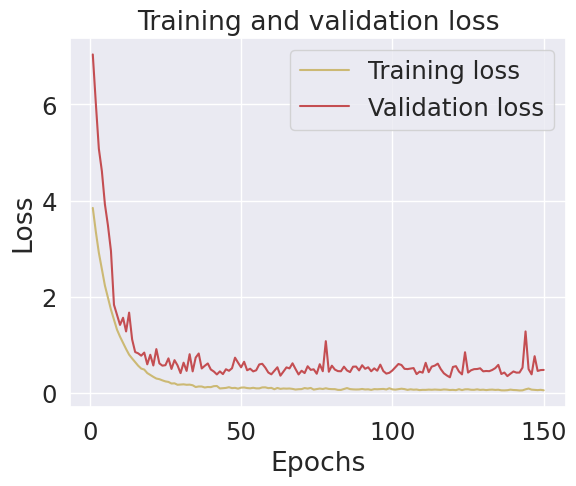

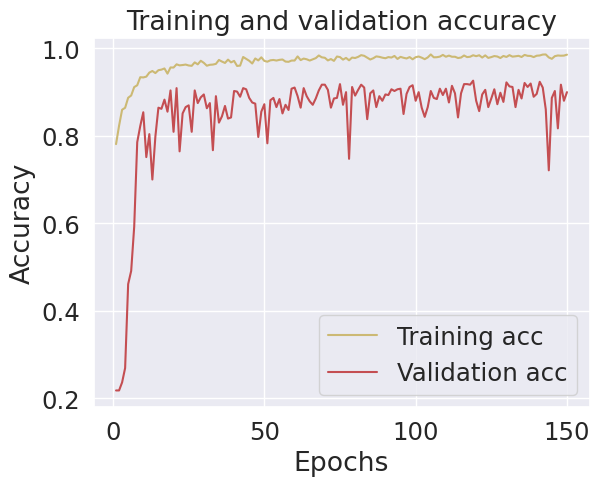

In [28]:
score = model.evaluate(valid_generator, verbose=0)
print('Test accuracy:', score[1])


#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **(D) TRAINED MODEL EVALUATION**

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Cohen's Kappa Score: 0.8749
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        46
           1       0.95      0.90      0.92        39
           2       0.78      0.89      0.83        36
           3       0.89      0.86      0.87        28
           4       0.90      0.86      0.88        42

    accuracy                           0.90       191
   macro avg       0.90      0.90      0.90       191
weighted avg       0.90      0.90      0.90       191



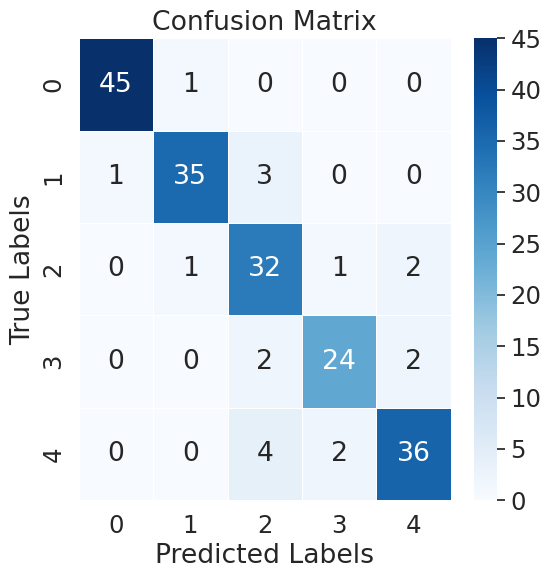

In [29]:
from sklearn.metrics import cohen_kappa_score, classification_report, confusion_matrix

# Load the best model weights
model.load_weights("/content/drive/MyDrive/MS_Project/Baseline.keras")  # Update with the actual path to the best weights

# Prediction on test data
y_pred = model.predict(testd_generator)
# Convert predictions classes to one-hot vectors
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert test data to one-hot vectors
y_true = np.argmax(y_tst, axis=1)

# Cohen's Kappa Score
kappa = cohen_kappa_score(y_true, y_pred_classes)
print(f"Cohen's Kappa Score: {kappa:.4f}")

# Precision, Recall, F1-Score
report = classification_report(y_true, y_pred_classes)
print("Classification Report:\n", report)

# Print confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(6, 6))
sns.set(font_scale=1.6)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=.5, ax=ax)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Including Explainability

# End of Multiclass Baseline Code!